In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.tree import plot_tree


In [94]:
# Load Data
df = pd.read_csv("C:/Users/dell/Desktop/university/semester_6/intilligint programming/project/Heart_Disease_Detection/cleaned_data.csv")

# Convert boolean if exists
df = df.replace({True: 1, False: 0})

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (305, 20)


C:\Users\dell\AppData\Local\Temp\ipykernel_17976\3522703768.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,0.479167,1,0.407895,0.354639,0,0.706897,0,0.250,2,0,0,0,0,1,0,0,1,0,0,1
1,0.500000,1,0.605263,0.317526,1,0.594828,1,0.775,0,0,0,0,0,0,0,0,0,0,0,1
2,0.854167,1,0.671053,0.197938,0,0.336207,1,0.650,0,0,0,0,0,1,0,0,0,0,0,1
3,0.666667,1,0.710526,0.317526,0,0.646552,0,0.000,1,0,0,0,0,1,0,0,1,0,0,1
4,0.687500,0,0.578947,0.692784,1,0.172414,0,0.475,3,0,0,0,0,1,0,1,0,0,1,0


In [95]:
# Split Features & Target
X = df.drop("target", axis=1)
y = df["target"]

In [96]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (244, 19)
Test: (61, 19)


In [97]:
# Train Decision Tree
model = DecisionTreeClassifier(criterion="entropy",random_state=42,ccp_alpha=0.01)

model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.01, criterion='entropy', random_state=42)

In [98]:
# Predictions
y_pred = model.predict(X_test) 


In [99]:
# Evaluation Metrics 
print("Accuracy:", accuracy_score(y_test, y_pred)) 
print("Precision:", precision_score(y_test, y_pred)) 
print("Recall:", recall_score(y_test, y_pred)) 
print("F1 Score:", f1_score(y_test, y_pred)) 
print("\nClassification Report:\n") 
print(classification_report(y_test, y_pred))


Accuracy: 0.7868852459016393
Precision: 0.7777777777777778
Recall: 0.8484848484848485
F1 Score: 0.8115942028985508

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.71      0.75        28
           1       0.78      0.85      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



In [100]:
# Hyperparameter Tuning
param_grid = {
    "max_depth": [5, 10, 15,20, None],
    "min_samples_split": [2, 5, 10,20],
    "min_samples_leaf": [1, 2, 5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [101]:
# Best Model Evaluation
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned F1 Score:", f1_score(y_test, y_pred_best))

Tuned Model Accuracy: 0.7540983606557377
Tuned F1 Score: 0.782608695652174


In [102]:
# Save Model
joblib.dump(best_model, "decision_tree_model.pkl")

print("Model saved successfully!")

Model saved successfully!


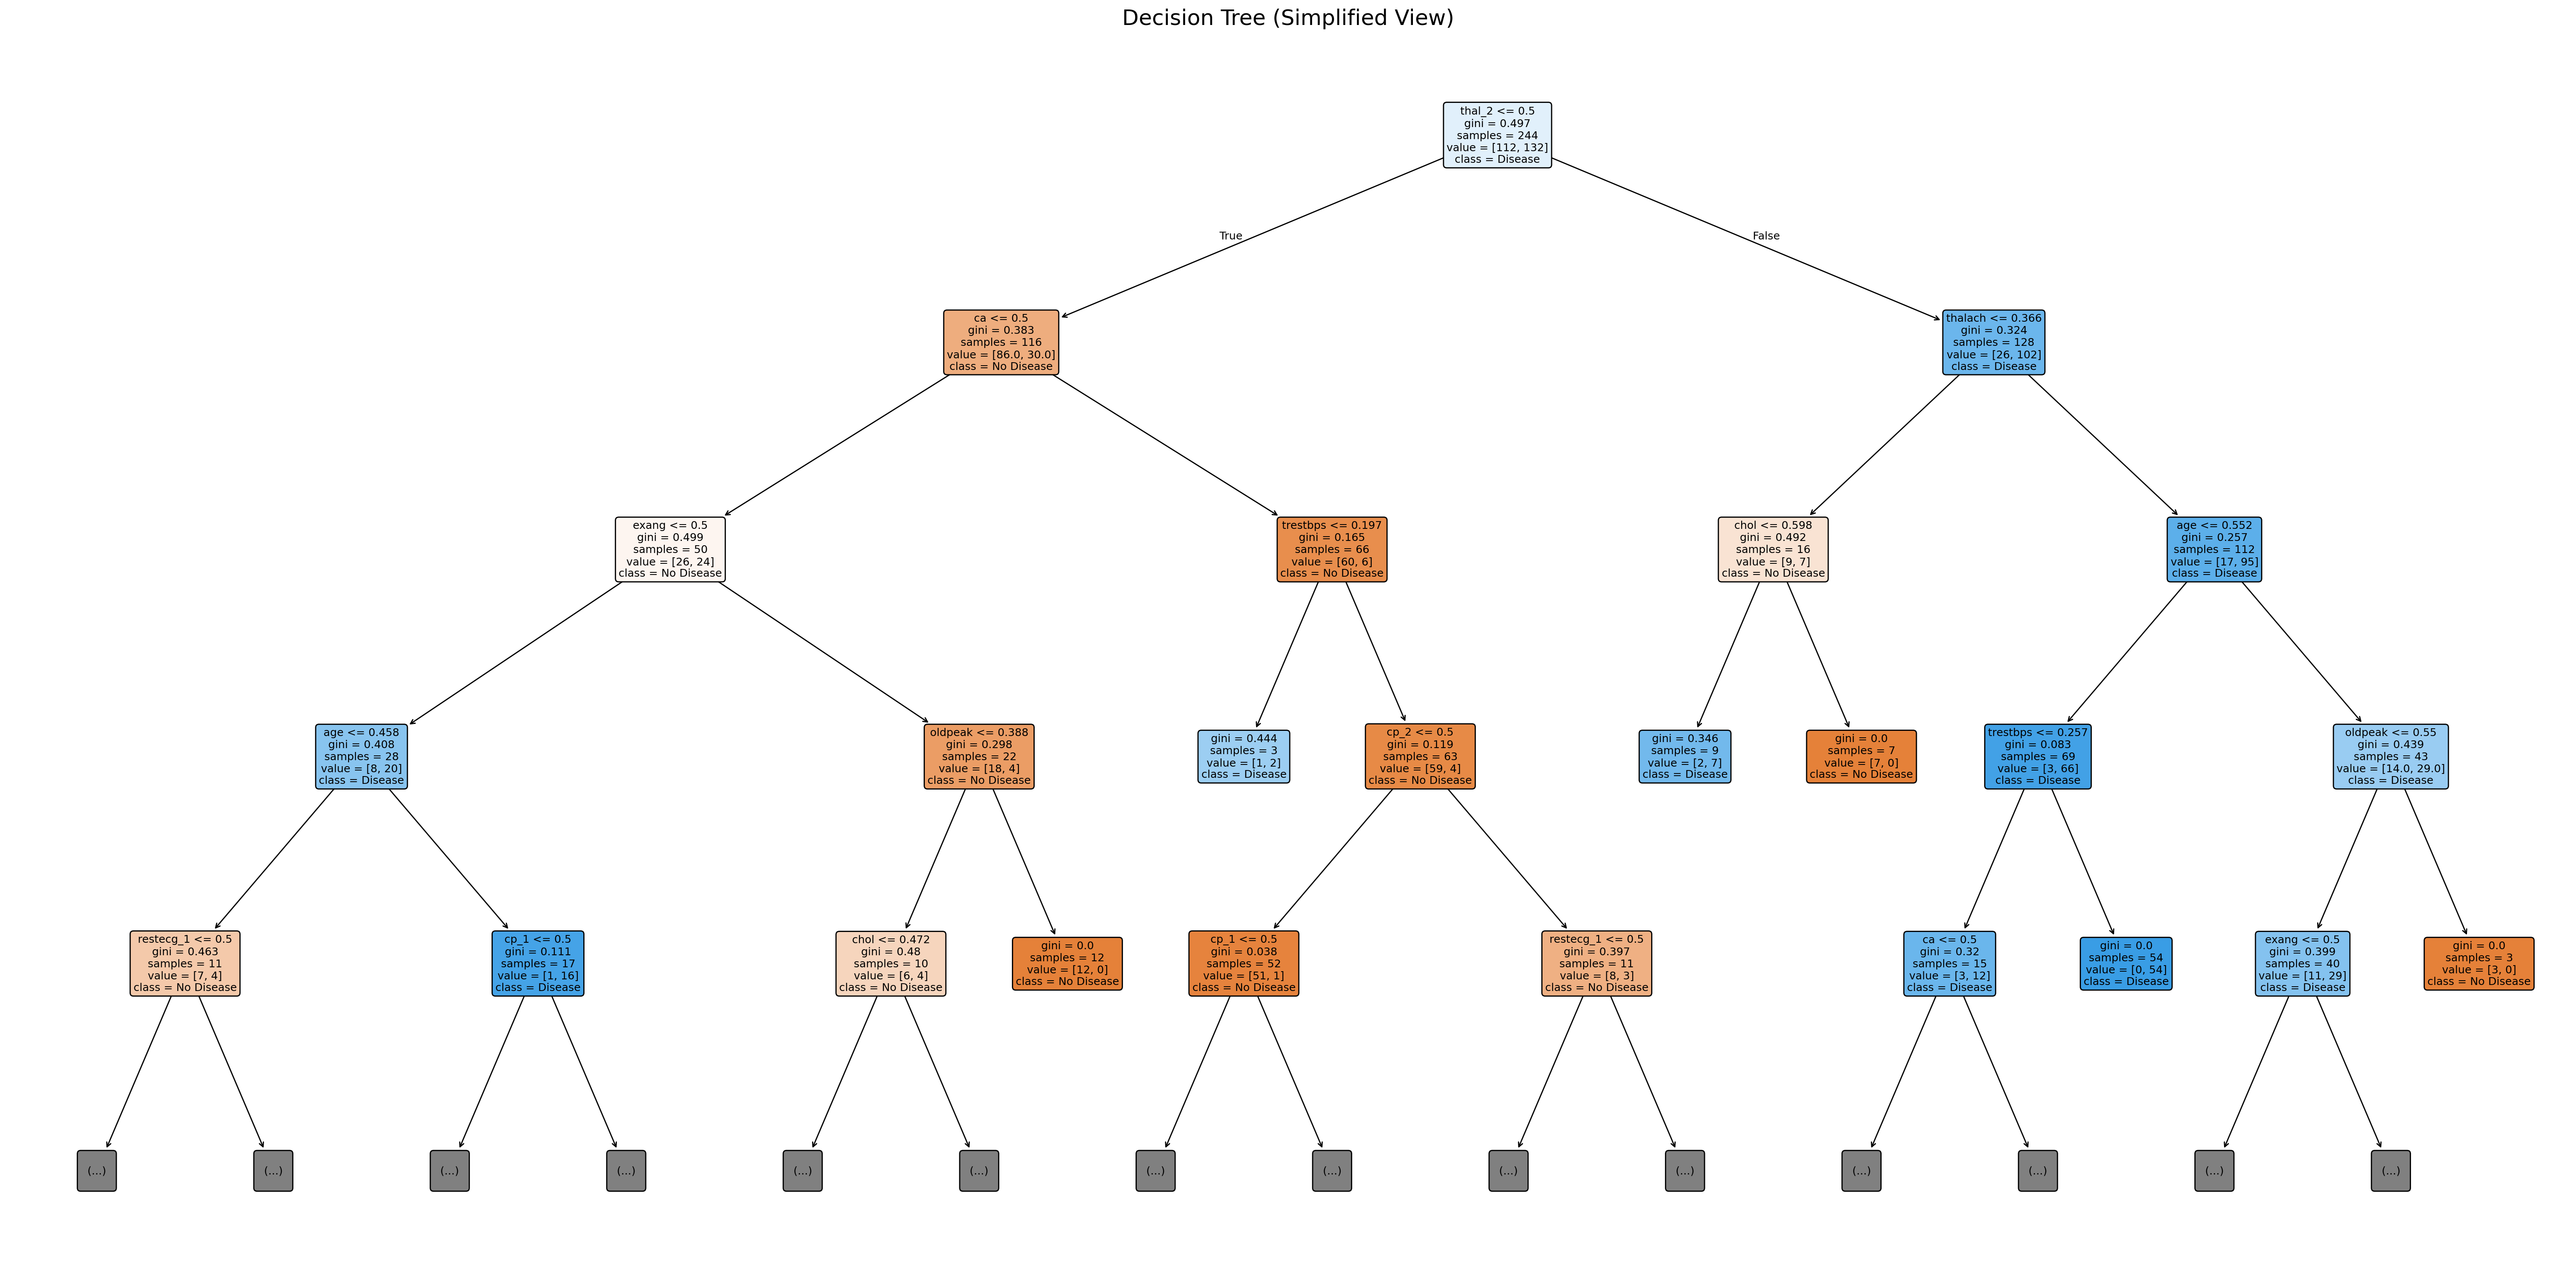

In [103]:
plt.figure(figsize=(30, 15), dpi=200)

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=4   
)

plt.title("Decision Tree (Simplified View)", fontsize=18)
plt.tight_layout()
plt.show()